<a href="https://colab.research.google.com/github/EmperorRP/ba-820-team-a107/blob/main/notebooks/m5/M5_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sentence_transformers import SentenceTransformer
import umap
import hdbscan


import nbformat
from IPython.display import display, Markdown, Code

warnings.filterwarnings("ignore")

# Load the shared dataset
drugs = pd.read_csv('/content/drive/MyDrive/drugs.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
drugs.head()

,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,marketing_authorisation_holder_company_name,pharmacotherapeutic_group,date_of_opinion,decision_date,revision_number,condition_indication,species,first_published,revision_date,url
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,Takeda Pharma A/S,Antineoplastic agents,2012-07-19,2022-11-17,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,2018-07-25T13:58:00Z,2023-03-13T11:52:00Z,https://www.ema.europa.eu/en/medicines/human/E...
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,Cycle Pharmaceuticals (Europe) Ltd,"Other alimentary tract and metabolism products,",2018-05-31,2023-03-10,4.0,Treatment of adult and paediatric patients wit...,NaN,2018-07-26T14:20:00Z,2023-03-10T17:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,NaN,True,...,Pierre Fabre Medicament,NaN,2022-10-13,2023-03-09,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,2022-10-12T16:13:00Z,2023-03-10T13:40:00Z,https://www.ema.europa.eu/en/medicines/human/E...
3,human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",5814,False,authorised,J06BD,True,...,Roche Registration GmbH,"Immune sera and immunoglobulins,",2021-11-11,2023-02-24,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,2021-11-12T16:30:00Z,2023-03-10T12:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...
4,human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,secukinumab,3729,False,authorised,L04AC10,False,...,Novartis Europharm Limited,Immunosuppressants,2014-11-20,2023-01-26,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,2018-06-07T11:59:00Z,2023-03-09T18:53:00Z,https://www.ema.europa.eu/en/medicines/human/E...


In [3]:
# Install nbformat to read .ipynb files
# !pip install nbformatﬁˇ

In [4]:
def get_code_cells_from_ipynb(filepath):
    """Reads an .ipynb file and returns a list of code cell sources."""
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            notebook_content = nbformat.read(f, as_version=4)
        code_cells = []
        for cell in notebook_content.cells:
            if cell.cell_type == 'code':
                code_cells.append(cell.source)
        return code_cells
    except FileNotFoundError:
        print(f"Error: Notebook not found at {filepath}")
        return []
    except Exception as e:
        print(f"Error reading notebook {filepath}: {e}")
        return []

notebook_files = {
    "Keane's M4 Notebook": '/content/M4_Final_Keane.ipynb',
    "Brian's M4 Notebook": '/content/BrianPark_M4.ipynb',
    "Rahul's M4 Notebook": '/content/Rahul_M4.ipynb',
    "Alex's M4 Notebook": '/content/Alex medicines EDA M4.ipynb'
}

all_integrated_code = {}
for name, filepath in notebook_files.items():
    all_integrated_code[name] = get_code_cells_from_ipynb(filepath)

for notebook_name, code_blocks in all_integrated_code.items():
    if code_blocks:
        print(f"--- Generating content for {notebook_name} ---")
        # Generating markdown header
        display(Markdown(f"## Integrated Code from {notebook_name}"))
        # Generating code cells
        for i, code in enumerate(code_blocks):
            print(f"### Cell {i+1} from {notebook_name}")
            display(Code(code, language='python'))
    else:
        display(Markdown(f"## No Code Cells Found in {notebook_name} or File Not Found"))


Error: Notebook not found at /content/M4_Final_Keane.ipynb
Error: Notebook not found at /content/BrianPark_M4.ipynb
Error: Notebook not found at /content/Rahul_M4.ipynb
Error: Notebook not found at /content/Alex medicines EDA M4.ipynb


## No Code Cells Found in Keane's M4 Notebook or File Not Found

## No Code Cells Found in Brian's M4 Notebook or File Not Found

## No Code Cells Found in Rahul's M4 Notebook or File Not Found

## No Code Cells Found in Alex's M4 Notebook or File Not Found

## Integrated Code from Keane's M4 Notebook

### Cell 2 from Keane's M4 Notebook

In [5]:
drugs = pd.read_csv('/content/drive/MyDrive/drugs.csv')

### Cell 3 from Keane's M4 Notebook

In [6]:
drugs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 28 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   category                                     1988 non-null   object 
 1   medicine_name                                1988 non-null   object 
 2   therapeutic_area                             1703 non-null   object 
 3   common_name                                  1984 non-null   object 
 4   active_substance                             1987 non-null   object 
 5   product_number                               1988 non-null   int64  
 6   patient_safety                               1988 non-null   bool   
 7   authorisation_status                         1987 non-null   object 
 8   atc_code                                     1960 non-null   object 
 9   additional_monitoring                        1988 non-null   bool   
 10  

### Cell 4 from Keane's M4 Notebook

In [7]:
drugs['decision_date'] = pd.to_datetime(drugs['decision_date'], errors='coerce')
drugs['approval_year'] = drugs['decision_date'].dt.year
drugs_approved_per_year = drugs['approval_year'].value_counts().sort_index()

print("Approval trends:")
display(drugs_approved_per_year.head(10))
display(drugs_approved_per_year.tail(10))

Approval trends:


,count
approval_year,
1998.0,1
1999.0,1
2000.0,2
2001.0,3
2002.0,8
2003.0,5
2004.0,9
2005.0,5
2006.0,8


,count
approval_year,
2014.0,31
2015.0,30
2016.0,33
2017.0,37
2018.0,54
2019.0,59
2020.0,100
2021.0,381
2022.0,794


### Cell 5 from Keane's M4 Notebook

In [8]:
drugs.head(5)

,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,pharmacotherapeutic_group,date_of_opinion,decision_date,revision_number,condition_indication,species,first_published,revision_date,url,approval_year
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,Antineoplastic agents,2012-07-19,2022-11-17,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,2018-07-25T13:58:00Z,2023-03-13T11:52:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2022.0
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,"Other alimentary tract and metabolism products,",2018-05-31,2023-03-10,4.0,Treatment of adult and paediatric patients wit...,NaN,2018-07-26T14:20:00Z,2023-03-10T17:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2023.0
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,NaN,True,...,NaN,2022-10-13,2023-03-09,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,2022-10-12T16:13:00Z,2023-03-10T13:40:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2023.0
3,human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",5814,False,authorised,J06BD,True,...,"Immune sera and immunoglobulins,",2021-11-11,2023-02-24,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,2021-11-12T16:30:00Z,2023-03-10T12:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2023.0
4,human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,secukinumab,3729,False,authorised,L04AC10,False,...,Immunosuppressants,2014-11-20,2023-01-26,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,2018-06-07T11:59:00Z,2023-03-09T18:53:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2023.0


### Cell 6 from Keane's M4 Notebook

In [9]:
missing_cols = drugs.columns[drugs.isnull().any()].tolist()

missingness_df = drugs[missing_cols].isnull().astype(int)

print("Missingness Pattern (first 5 rows):")
display(missingness_df.head())

Missingness Pattern (first 5 rows):


,therapeutic_area,common_name,active_substance,authorisation_status,atc_code,marketing_authorisation_date,date_of_refusal_of_marketing_authorisation,marketing_authorisation_holder_company_name,pharmacotherapeutic_group,date_of_opinion,decision_date,revision_number,condition_indication,species,revision_date,approval_year
0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
2,0,0,0,0,1,0,1,0,1,0,0,0,0,1,0,0
3,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0


### Cell 7 from Keane's M4 Notebook

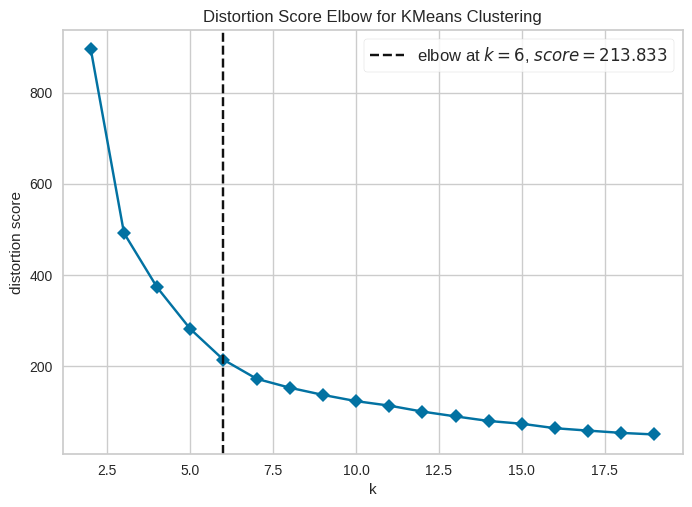

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [10]:
# Instantiate the clustering model with the optimal number of clusters
# A common heuristic is to use n_init=10 to run KMeans 10 times with different centroid seeds
clustering = KMeans(random_state=42, n_init=10)

# Use Yellowbrick's KElbowVisualizer to find the optimal k
visualizer = KElbowVisualizer(
    clustering, k=(2, 20), metric='distortion', timings=False, random_state=42
)

visualizer.fit(missingness_df)
visualizer.show()

## Integrated Code from Brian's M4 Notebook

In [11]:
# BioBERT implementation
drugs['condition_indication'] = drugs['condition_indication'].fillna('')

med_transformer = SentenceTransformer('NeuML/pubmedbert-base-embeddings')
X_embeddings = med_transformer.encode(drugs['condition_indication'].tolist(), show_progress_bar=True)

print(f"\n--- BioBERT Embedding Result ---")
print(f"Matrix Shape: {X_embeddings.shape} (Rows, Dimensions)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]


--- BioBERT Embedding Result ---
Matrix Shape: (1988, 768) (Rows, Dimensions)


--- M4 Text Sequence Length Analysis ---
Max Word Count: 1092
Average Word Count: 70.1
95th Percentile: 226.6


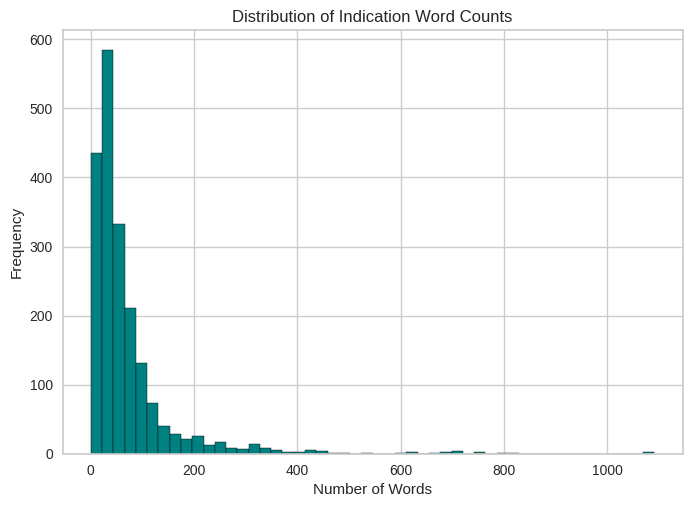

In [12]:
# Word Count Visualization
drugs['word_count'] = drugs['condition_indication'].apply(lambda x: len(str(x).split()))

print("--- M4 Text Sequence Length Analysis ---")
print(f"Max Word Count: {drugs['word_count'].max()}")
print(f"Average Word Count: {drugs['word_count'].mean():.1f}")
print(f"95th Percentile: {drugs['word_count'].quantile(0.95):.1f}")

plt.hist(drugs['word_count'], bins=50, color='teal', edgecolor='black')
plt.title("Distribution of Indication Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [13]:
reducer_cluster = umap.UMAP(n_neighbors=15, n_components=5, metric='cosine', random_state=42)
X_umap_cluster = reducer_cluster.fit_transform(X_embeddings)

reducer_3d = umap.UMAP(n_neighbors=15, n_components=3, metric='cosine', random_state=42)
X_umap_3d = reducer_3d.fit_transform(X_embeddings)

drugs['umap_x'] = X_umap_3d[:, 0]
drugs['umap_y'] = X_umap_3d[:, 1]
drugs['umap_z'] = X_umap_3d[:, 2]

print("\n--- UMAP Result ---")
print(f"Clustering Matrix Shape: {X_umap_cluster.shape}")
print(f"Visualization Matrix Shape: {X_umap_3d.shape}")


--- UMAP Result ---
Clustering Matrix Shape: (1988, 5)
Visualization Matrix Shape: (1988, 3)


In [14]:
# HDBSCAN initialization and integratino with UMAP clusters

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15, # Minimum grouping to consider a valid therapeutic area
    min_samples=5,       # Control for clustering (higher = more drugs marked as outliers)
    metric='euclidean'   # We use euclidean here because UMAP already perfectly arranged the cosine geometry!
)

drugs['cluster_hdbscan'] = clusterer.fit_predict(X_umap_cluster)
n_clusters = len(set(drugs['cluster_hdbscan'])) - (1 if -1 in drugs['cluster_hdbscan'].values else 0)
n_outliers = list(drugs['cluster_hdbscan']).count(-1)

print(f"\n--- HDBSCAN Discovery ---")
print(f"Total Organic Clusters Found: {n_clusters}")
print(f"Total 'Blue Ocean' Outliers (-1): {n_outliers} drugs")

print("\nCluster Size Distribution (Top 10):")
# -1 will likely be the largest "group", which is perfectly normal for text data!
print(drugs['cluster_hdbscan'].value_counts().head(10))


--- HDBSCAN Discovery ---
Total Organic Clusters Found: 56
Total 'Blue Ocean' Outliers (-1): 244 drugs

Cluster Size Distribution (Top 10):
cluster_hdbscan
-1     244
 10    170
 6      78
 3      58
 48     48
 53     46
 31     45
 8      45
 24     41
 13     40
Name: count, dtype: int64


In [ ]:
# HDBSCAN Cluster Visualization

drugs['cluster_hdbscan_str'] = drugs['cluster_hdbscan'].astype(str)
color_map = {'-1': 'lightgray'}

drugs['short_indication'] = drugs['condition_indication'].apply(
    lambda x: str(x)[:120] + "..." if len(str(x)) > 120 else str(x)
)

# 4. Generate the Interactive 3D Plot
fig = px.scatter_3d(
    drugs,
    x='umap_x',
    y='umap_y',
    z='umap_z',
    color='cluster_hdbscan_str',
    color_discrete_map=color_map,
    hover_name='medicine_name',
    hover_data={
        'short_indication': True,
        'cluster_hdbscan_str': False, # Hide the string version
        'cluster_hdbscan': True,      # Show the actual number
        'umap_x': False,
        'umap_y': False,
        'umap_z': False
    },
    title='M4 Refinement: BioBERT + UMAP Semantic Landscape'
)

# 5. Styling to make it readable
fig.update_traces(marker=dict(size=4, opacity=0.8, line=dict(width=0)))
fig.update_layout(legend_title_text='Cluster ID ( -1 = Outliers )')

# fig.show() #comment back for full rotating visualization

In [16]:
crosstab_m4 = pd.crosstab(drugs['cluster_hdbscan'], drugs['category'])
overlap_clusters = crosstab_m4[(crosstab_m4['human'] > 0) & (crosstab_m4['veterinary'] > 0)]
overlap_clusters = overlap_clusters.drop(-1, errors='ignore')
print("--- 'One Health' Overlap Clusters (BioBERT + HDBSCAN) ---")
print(overlap_clusters)

--- 'One Health' Overlap Clusters (BioBERT + HDBSCAN) ---
category         human  veterinary
cluster_hdbscan                   
0                   25           1
8                   44           1
10                 166           4
16                  19           1
17                  13           6
24                  39           2
29                  15          14
31                  44           1
34                  14           1
35                  12           5
49                  31           1
54                  37           1


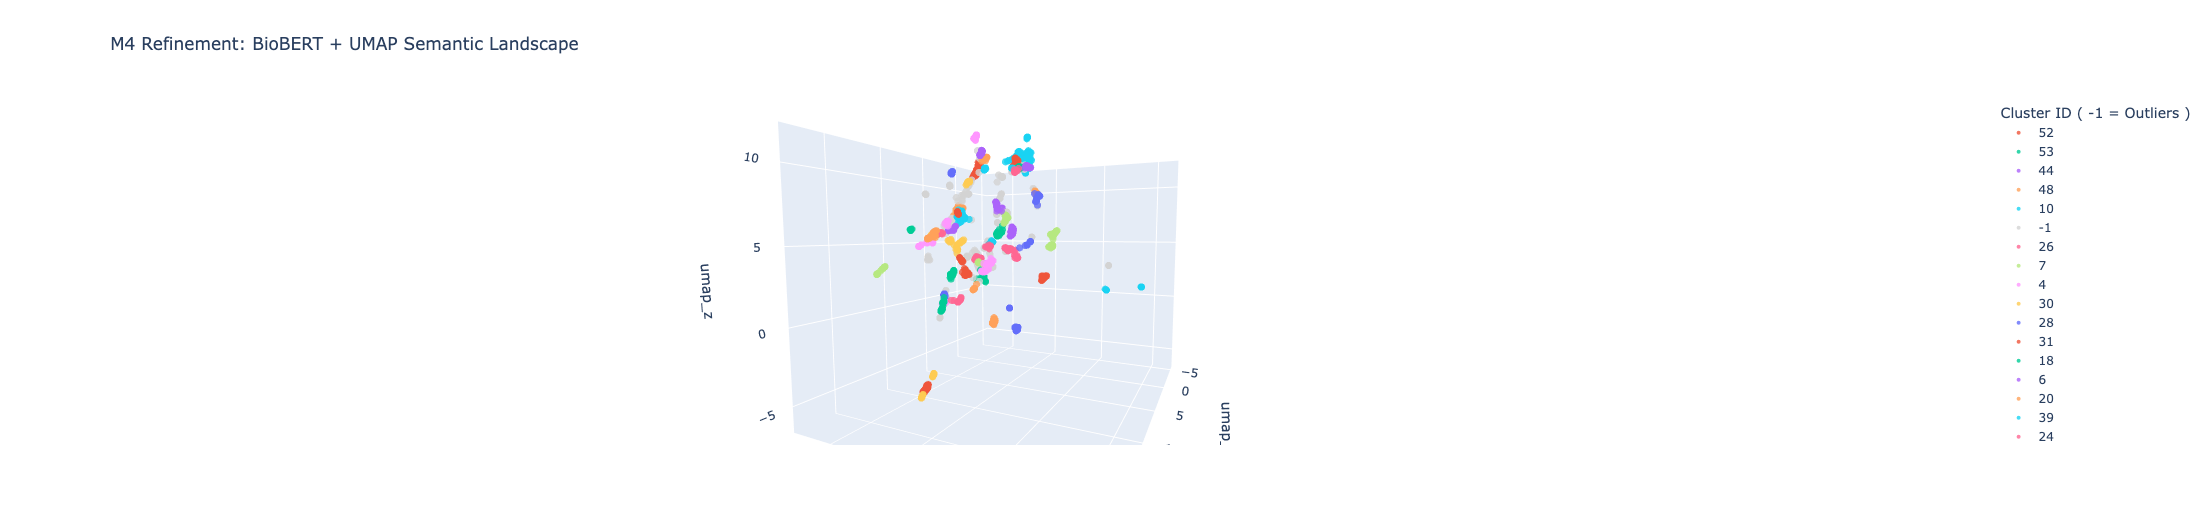

The following output shows a closer examination of the medicine name and `condition_indication` of Cluster 29.

In [17]:
target_cluster = 29

human_drugs = drugs[(drugs['cluster_hdbscan'] == target_cluster) & (drugs['category'] == 'human')]
print(f"\nHUMAN DRUGS ({len(human_drugs)} total):")
for index, row in human_drugs.head(5).iterrows():
    print(f" • {row['medicine_name']}: {str(row['condition_indication'])[:150]}...")

# 2. Print Veterinary Examples
vet_drugs = drugs[(drugs['cluster_hdbscan'] == target_cluster) & (drugs['category'] == 'veterinary')]
print(f"\nVETERINARY DRUGS ({len(vet_drugs)} total):")
for index, row in vet_drugs.head(5).iterrows():
    print(f" • {row['medicine_name']}: {str(row['condition_indication'])[:150]}...")


HUMAN DRUGS (15 total):
 • Aloxi: Aloxi is indicated in adults for:the prevention of acute nausea and vomiting associated with highly emetogenic cancer chemotherapy,the prevention of n...
 • Akynzeo: Akynzeo is indicated in adults for the:, , , 	Prevention of acute and delayed nausea and vomiting associated with highly emetogenic cisplatin based ca...
 • Byfavo: Remimazolam is indicated in adults for procedural sedation.,...
 • Dexmedetomidine Accord: For sedation of adult ICU (Intensive Care Unit) patients requiring a sedation level not deeper than arousal in response to verbal stimulation (corresp...
 • Sugammadex Amomed: Reversal of neuromuscular blockade induced by rocuronium or vecuronium.For the paediatric population: sugammadex is only recommended for routine rever...

VETERINARY DRUGS (14 total):
 • Zenalpha: To provide restraint, sedation and analgesia during conduct of non-invasive, non-painful or mildly painful procedures and examinations intended to las...
 • Tessie: Allev

## Integrated Code from Rahul's M4 Notebook

### Cell 1 from Rahul's M4 Notebook

In [18]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

df_q = drugs.copy()
df_q = df_q.dropna(subset=["authorisation_status"]).copy()

df_q["authorisation_status"] = df_q["authorisation_status"].astype(str).str.strip().str.lower()
allowed_outcomes = {"authorised", "withdrawn", "refused"}
df_q = df_q[df_q["authorisation_status"].isin(allowed_outcomes)].copy()

### Cell 2 from Rahul's M4 Notebook

In [19]:
def clean_area_string(s: str) -> str:
    """Normalize therapeutic area label spacing/casing without over-normalizing semantics."""
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def split_areas(s: str, delimiter=";"):
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return []
    s = clean_area_string(s)
    if not s:
        return []
    parts = [p.strip() for p in s.split(delimiter)]
    parts = [p for p in parts if p]
    return parts

# Track B (explode multi-labels)
df_B = df_q.copy()
df_B["therapeutic_area_list"] = df_B["therapeutic_area"].apply(split_areas)
df_B = df_B.explode("therapeutic_area_list").rename(columns={"therapeutic_area_list": "therapeutic_area_clean"})
df_B["therapeutic_area_clean"] = df_B["therapeutic_area_clean"].apply(clean_area_string)
df_B = df_B[df_B["therapeutic_area_clean"].notna()].copy()

### Cell 3 from Rahul's M4 Notebook

In [20]:
def build_profiles(df_in: pd.DataFrame, area_col: str, outcome_col: str, min_n: int = 30) -> pd.DataFrame:
    ct = pd.crosstab(df_in[area_col], df_in[outcome_col])
    for oc in ["authorised", "withdrawn", "refused"]:
        if oc not in ct.columns:
            ct[oc] = 0
    ct = ct[["authorised", "withdrawn", "refused"]]
    ct["n_total"] = ct.sum(axis=1)
    ct = ct[ct["n_total"] >= min_n].copy()
    for oc in ["authorised", "withdrawn", "refused"]:
        ct[f"p_{oc}"] = ct[oc] / ct["n_total"]
    ct = ct.sort_values("n_total", ascending=False)
    return ct

MIN_N = 30
profiles_B = build_profiles(df_B, "therapeutic_area_clean", "authorisation_status", min_n=MIN_N)
print("High-volume areas (Track B):", profiles_B.shape[0])
display(profiles_B.head())

High-volume areas (Track B): 17


authorisation_status,authorised,withdrawn,refused,n_total,p_authorised,p_withdrawn,p_refused
therapeutic_area_clean,,,,,,,
"Diabetes Mellitus, Type 2",61,16,0,77,0.792208,0.207792,0.000000
HIV Infections,62,12,0,74,0.837838,0.162162,0.000000
Breast Neoplasms,51,10,2,63,0.809524,0.158730,0.031746
"Carcinoma, Non-Small-Cell Lung",47,13,1,61,0.770492,0.213115,0.016393
Immunization,25,27,0,52,0.480769,0.519231,0.000000


## Integrated Code from Alex's M4 Notebook

### Cell 1 from Alex's M4 Notebook

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.metrics.pairwise import cosine_similarity

# Operating on a fresh copy of the shared dataset to preserve Alex's workflow
df_alex = drugs.copy()

### Cell 2 from Alex's M4 Notebook

In [22]:
# 1. Text Preprocessing Upgrade — Regex-Based Cleaning
def clean_text(text):
    """Clean text using regex: lowercase, remove non-alphabetic chars, collapse whitespace."""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

text_raw = df_alex["condition_indication"].fillna("").astype(str)
text_clean = text_raw.apply(clean_text)

### Cell 3 from Alex's M4 Notebook

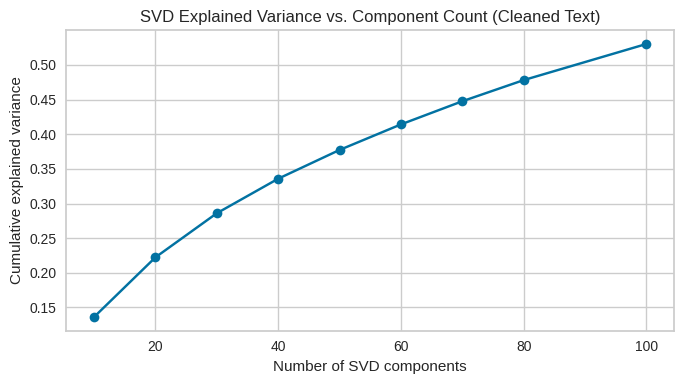

In [23]:
# 2. SVD Component Tuning
tfidf_m4 = TfidfVectorizer(stop_words="english", min_df=5, max_df=0.85)
X_tfidf_m4 = tfidf_m4.fit_transform(text_clean)

n_components_range = [10, 20, 30, 40, 50, 60, 70, 80, 100]
explained = []

for n in n_components_range:
    svd_test = TruncatedSVD(n_components=n, random_state=42)
    svd_test.fit(X_tfidf_m4)
    explained.append(svd_test.explained_variance_ratio_.sum())

plt.figure(figsize=(7, 4))
plt.plot(n_components_range, explained, marker="o")
plt.xlabel("Number of SVD components")
plt.ylabel("Cumulative explained variance")
plt.title("SVD Explained Variance vs. Component Count (Cleaned Text)")
plt.grid(True)
plt.tight_layout()
plt.show()

### Cell 4 from Alex's M4 Notebook

In [24]:
# 3. Build feature matrix
flag_cols = ["patient_safety", "additional_monitoring", "generic", "biosimilar",
             "conditional_approval", "exceptional_circumstances",
             "accelerated_assessment", "orphan_medicine"]

df_alex["auth_year"] = pd.to_datetime(df_alex["marketing_authorisation_date"], errors='coerce').dt.year
df_alex["decision_year"] = pd.to_datetime(df_alex["decision_date"], errors='coerce').dt.year

svd = TruncatedSVD(n_components=50, random_state=42)
X_text = svd.fit_transform(X_tfidf_m4)

X_num = df_alex[flag_cols + ["auth_year", "decision_year"]].copy()

# convert booleans/years to numeric safely
for c in flag_cols:
    X_num[c] = X_num[c].astype(float)
for c in ["auth_year", "decision_year"]:
    X_num[c] = pd.to_numeric(X_num[c], errors="coerce")

X_num = X_num.fillna(X_num.median(numeric_only=True))
X_num_scaled = StandardScaler().fit_transform(X_num)

X_m4 = np.hstack([X_text, X_num_scaled])

# Evaluate KMeans k range
inertias = []
sils = []
Ks = range(2, 26)

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_m4)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_m4, labels))

best_k_m4 = Ks[int(np.argmax(sils))]
km_final = KMeans(n_clusters=best_k_m4, random_state=42, n_init="auto")
df_alex["kmeans_cluster_m4"] = km_final.fit_predict(X_m4)

### Cell 5 from Alex's M4 Notebook

In [25]:
# 4. N-gram TF-IDF Comparison — Capturing Multi-Word Context
tfidf_bigram = TfidfVectorizer(stop_words="english", min_df=5, max_df=0.85, ngram_range=(1, 2))
X_tfidf_bigram = tfidf_bigram.fit_transform(text_clean)

svd_bigram = TruncatedSVD(n_components=50, random_state=42)
X_text_bigram = svd_bigram.fit_transform(X_tfidf_bigram)
X_combined_bigram = np.hstack([X_text_bigram, X_num_scaled])

try:
    pca_bigram = PCA(n_components=0.95, random_state=42)
    X_bigram = pca_bigram.fit_transform(X_combined_bigram)
except:
    X_bigram = X_combined_bigram

sils_bigram = []
for k in Ks:
    km_bg = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labs_bg = km_bg.fit_predict(X_bigram)
    sils_bigram.append(silhouette_score(X_bigram, labs_bg))

best_k_bigram = list(Ks)[int(np.argmax(sils_bigram))]

### Cell 6 from Alex's M4 Notebook

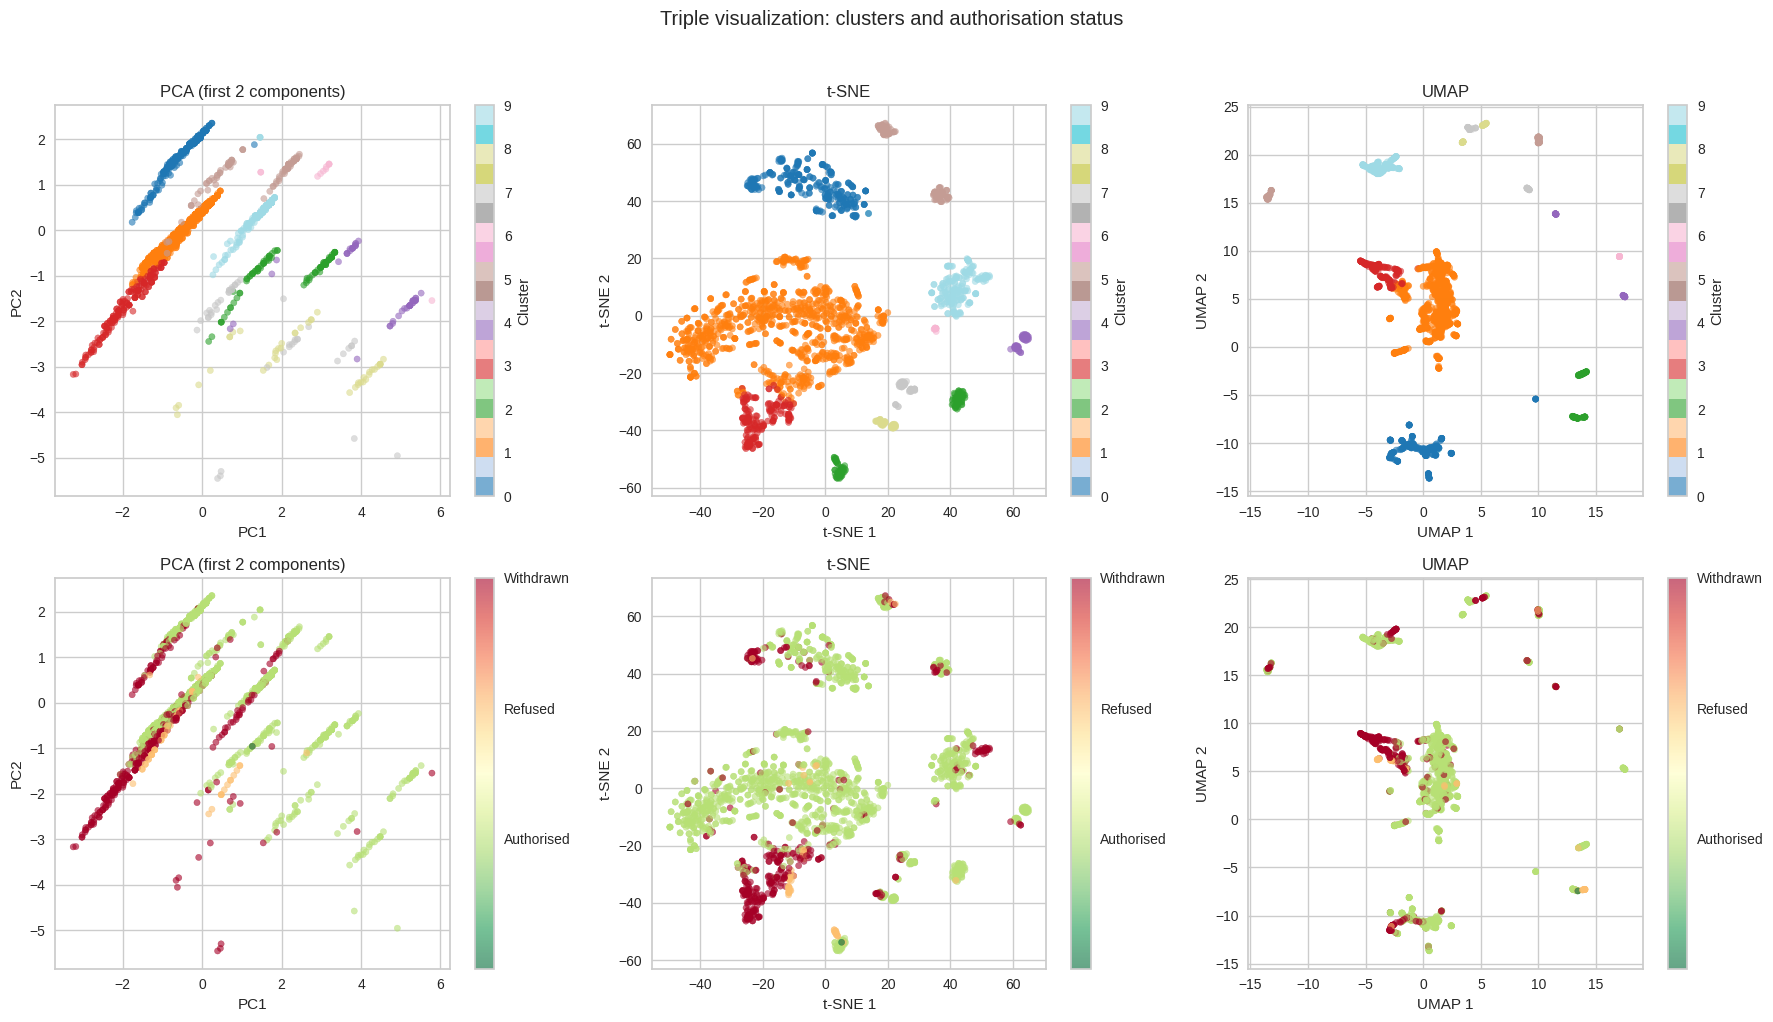

In [26]:
# 5. Triple visualization: PCA, t-SNE, UMAP
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42)
    X_umap = reducer.fit_transform(X_m4)
    has_umap = True
except ImportError:
    has_umap = False
    print("UMAP not installed. Run: pip install umap-learn")

from sklearn.manifold import TSNE
X_pca2 = PCA(n_components=2, random_state=42).fit_transform(X_m4)
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X_m4)

n_plots = 3 if has_umap else 2
fig, axes = plt.subplots(2, n_plots, figsize=(6 * n_plots, 10), squeeze=False)

status_map = {"authorised": 0, "refused": 1, "withdrawn": 2}
status_num = df_alex["authorisation_status"].str.lower().map(status_map).fillna(-1).astype(int)

projs = [(X_pca2, "PCA (first 2 components)", "PC1", "PC2"),
         (X_tsne, "t-SNE", "t-SNE 1", "t-SNE 2")]
if has_umap:
    projs.append((X_umap, "UMAP", "UMAP 1", "UMAP 2"))

for j, (coords, title, xl, yl) in enumerate(projs):
    ax = axes[0, j]
    scatter = ax.scatter(coords[:, 0], coords[:, 1], c=df_alex["kmeans_cluster_m4"].values, cmap="tab20", alpha=0.6, s=20)
    ax.set_title(title)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    plt.colorbar(scatter, ax=ax, label="Cluster")

for j, (coords, title, xl, yl) in enumerate(projs):
    ax = axes[1, j]
    scatter = ax.scatter(coords[:, 0], coords[:, 1], c=status_num.values, cmap="RdYlGn_r", alpha=0.6, s=20)
    ax.set_title(title)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_ticks([0, 1, 2])
    cbar.set_ticklabels(["Authorised", "Refused", "Withdrawn"])

plt.suptitle("Triple visualization: clusters and authorisation status", y=1.02)
plt.tight_layout()
plt.show()

### Cell 7 from Alex's M4 Notebook

In [27]:
# 6. Cosine similarity between cluster centroids (TF-IDF space)
centroids = []
for c in range(best_k_m4):
    indices = np.where(df_alex["kmeans_cluster_m4"].values == c)[0]
    if len(indices) == 0:
        centroids.append(np.zeros(X_tfidf_m4.shape[1]))
    else:
        cent = np.asarray(X_tfidf_m4[indices].mean(axis=0)).flatten()
        centroids.append(cent)
centroids = np.vstack(centroids)

cos_sim = cosine_similarity(centroids)
print("\nCosine similarity between cluster centroids (TF-IDF space):")
print(pd.DataFrame(cos_sim, index=range(best_k_m4), columns=range(best_k_m4)).round(3).to_string())


Cosine similarity between cluster centroids (TF-IDF space):
       0      1      2      3      4      5      6      7      8      9
0  1.000  0.791  0.674  0.660  0.579  0.569  0.296  0.524  0.490  0.699
1  0.791  1.000  0.712  0.804  0.587  0.626  0.415  0.651  0.576  0.818
2  0.674  0.712  1.000  0.565  0.694  0.556  0.340  0.588  0.599  0.749
3  0.660  0.804  0.565  1.000  0.437  0.514  0.351  0.518  0.475  0.633
4  0.579  0.587  0.694  0.437  1.000  0.487  0.356  0.507  0.545  0.711
5  0.569  0.626  0.556  0.514  0.487  1.000  0.389  0.412  0.392  0.599
6  0.296  0.415  0.340  0.351  0.356  0.389  1.000  0.309  0.338  0.477
7  0.524  0.651  0.588  0.518  0.507  0.412  0.309  1.000  0.512  0.627
8  0.490  0.576  0.599  0.475  0.545  0.392  0.338  0.512  1.000  0.599
9  0.699  0.818  0.749  0.633  0.711  0.599  0.477  0.627  0.599  1.000
